# Introduction

Ce projet porte sur l’analyse comparative de trois algorithmes de clustering appliqués au jeu de données Iris : **K-Means**, **Gaussian Mixture Model (GMM)** et **DBSCAN**. L’objectif est de comprendre le fonctionnement de ces méthodes non supervisées, d’étudier l’effet de leurs hyperparamètres et d’interpréter les groupes obtenus sur les données.

L’énoncé demande trois éléments principaux :  
- présenter le principe de fonctionnement du **GMM**
- implémenter une version simplifiée de **DBSCAN en Python sans utiliser scikit-learn pour cette partie**
- appliquer les trois algorithmes au dataset **Iris** afin d’analyser l’influence de leurs hyperparamètres sur le nombre de clusters, la structure des groupes et la présence de bruit, puis visualiser et interpréter les résultats

Dans ce travail, nous allons adopter une démarche progressive. Nous commencerons par explorer brièvement le dataset Iris, puis nous présenterons GMM, ensuite nous construirons une implémentation simplifiée de DBSCAN, et enfin nous comparerons les résultats obtenus avec K-Means, GMM et DBSCAN.

L’objectif n’est pas seulement d’obtenir des clusters, mais surtout de comprendre **dans quels cas chaque algorithme est plus adapté**. En effet, en apprentissage non supervisé, une bonne méthode de clustering doit produire des groupes avec une forte similarité interne et une faible similarité entre groupes. Le choix de l’algorithme dépend donc fortement de la structure des données.

#

# Présentation du dataset Iris et préparation des données

Dans cette étape, nous préparons le jeu de données **Iris** qui servira aux expérimentations avec **K-Means**, **GMM** et **DBSCAN**.

Le dataset Iris est un jeu de données classique en apprentissage automatique. Il contient des observations décrites par plusieurs variables numériques, ce qui en fait un bon support pour tester des méthodes de clustering.

Avant d’appliquer les algorithmes, il est important de :
- charger les données
- observer leur structure
- vérifier les dimensions du jeu de données
- examiner les variables disponibles
- préparer une version standardisée des données

Cette préparation est importante, car les méthodes fondées sur les distances peuvent être influencées par l’échelle des variables. Le cours rappelle en effet que les calculs de distance peuvent être dominés par certains attributs si les données ne sont pas mises à l’échelle correctement. La standardisation permet de transformer les variables pour qu’elles aient une moyenne proche de 0 et un écart-type proche de 1.

In [45]:
# importation des bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

# chargement du dataset iris
iris = load_iris()

# création d'un dataframe
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)

# ajout de la classe réelle seulement pour l'exploration visuelle
df_iris["species"] = iris.target
df_iris["species_name"] = df_iris["species"].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

# aperçu des données
print("aperçu du dataset iris :")
display(df_iris.head())

# dimensions du dataset
print("dimensions du dataset :", df_iris.shape)

# informations générales
print("\ninformations générales :")
df_iris.info()

# statistiques descriptives
print("\nstatistiques descriptives :")
display(df_iris.describe())

# séparation des variables numériques pour le clustering
X = df_iris[iris.feature_names]

# standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# conversion en dataframe pour un affichage plus clair
X_scaled_df = pd.DataFrame(X_scaled, columns=iris.feature_names)
print("valeurs manquantes par colonne :")
print(df_iris.isnull().sum())

print("\nnombre de doublons :", df_iris.duplicated().sum())

print("\napercu des données standardisées :")
display(X_scaled_df.head())

aperçu du dataset iris :


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


dimensions du dataset : (150, 6)

informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int32  
 5   species_name       150 non-null    object 
dtypes: float64(4), int32(1), object(1)
memory usage: 6.6+ KB

statistiques descriptives :


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


valeurs manquantes par colonne :
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64

nombre de doublons : 1

apercu des données standardisées :


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


## Interprétation des premiers résultats

Cet aperçu nous permet d’abord de vérifier que le dataset **Iris** a bien été chargé. On observe qu’il contient **150 observations** et que les données sont organisées dans un dataframe de **6 colonnes**.

Parmi ces colonnes, les **4 variables numériques** principales sont celles qui décrivent les caractéristiques des fleurs :
- `sepal length (cm)`
- `sepal width (cm)`
- `petal length (cm)`
- `petal width (cm)`

Les colonnes `species` et `species_name` ont été ajoutées uniquement pour nous aider à lire et interpréter les données. Elles ne seront pas utilisées comme entrée dans les algorithmes de clustering, puisque notre travail porte sur un apprentissage **non supervisé**.

La sortie de `info()` montre aussi que toutes les colonnes contiennent **150 valeurs non nulles**. Cela signifie qu’il n’y a **aucune valeur manquante** dans ce jeu de données, ce qui simplifie la préparation.

Les statistiques descriptives montrent ensuite que les variables n’ont pas exactement la même dispersion. Certaines colonnes varient sur des intervalles plus larges que d’autres. Même si les différences ne sont pas extrêmes, cela peut influencer les méthodes basées sur la distance.

C’est pour cette raison qu’une **standardisation** a été appliquée. Les valeurs standardisées affichées à la fin confirment que les données ont été transformées sur une échelle commune. Cette étape est importante pour préparer correctement l’application de **K-Means**, **GMM** et **DBSCAN**.

En résumé, cette première vérification montre que le dataset est :
- bien chargé
- complet
- propre
- et prêt pour les prochaines étapes du projet

#

# Présentation théorique du modèle GMM

Le **Gaussian Mixture Model (GMM)** est une méthode de clustering non supervisé basée sur une approche **probabiliste**. Contrairement à des méthodes plus simples qui attribuent directement chaque observation à un seul groupe, GMM suppose que les données proviennent d’un **mélange de plusieurs distributions gaussiennes**.

L’idée principale est la suivante : au lieu de dire qu’un point appartient de façon stricte à un cluster, GMM estime la **probabilité** qu’il appartienne à chacun des clusters. Ainsi, une même observation peut être fortement liée à un groupe, tout en gardant une certaine probabilité d’appartenir à un autre.

Dans ce modèle, chaque cluster est représenté par une loi gaussienne caractérisée par :
- une **moyenne**, qui indique le centre du groupe
- une **matrice de covariance**, qui décrit la forme, l’orientation et la dispersion du cluster
- un **poids**, qui représente l’importance relative de ce cluster dans l’ensemble des données

Cette approche rend GMM plus souple que plusieurs méthodes classiques de clustering, car les groupes ne sont pas forcément supposés être parfaitement sphériques ni de même taille.

En pratique, GMM cherche donc à modéliser les données comme une combinaison de plusieurs sous-populations gaussiennes. Chaque observation reçoit ensuite une probabilité d’appartenance à chacun des clusters, et elle peut finalement être associée au cluster pour lequel cette probabilité est la plus élevée.

## Fonctionnement général et intérêt de GMM

Le fonctionnement de GMM repose sur une logique itérative. Le modèle commence par estimer les paramètres initiaux des différentes gaussiennes, puis il répète deux étapes principales. D’abord, il calcule pour chaque observation la probabilité d’appartenir à chacun des clusters. Ensuite, il met à jour les paramètres des gaussiennes à partir de ces probabilités. Ce processus continue jusqu’à stabilisation.

La différence principale entre **GMM** et **K-Means** est que K-Means réalise une affectation directe de chaque point au centroïde le plus proche, alors que GMM adopte une approche probabiliste plus flexible. Cette différence est importante, car elle permet à GMM de mieux représenter des clusters qui ne sont pas forcément compacts ou sphériques.

Dans ce projet, GMM est donc intéressant parce qu’il apporte une vision différente du clustering. Il permettra de comparer une méthode probabiliste avec **K-Means**, basé sur les centroïdes, et **DBSCAN**, basé sur la densité.

#

# Implémentation manuelle simplifiée de DBSCAN

Dans cette partie, nous implémentons une version simplifiée de **DBSCAN** en Python, sans utiliser `scikit-learn`, comme demandé dans l’énoncé.

DBSCAN est une méthode de clustering basée sur la densité. Elle utilise deux paramètres :
- `eps` : rayon du voisinage
- `min_samples` : nombre minimum de points pour former une zone dense

L’algorithme distingue les points cœur, les points frontière et le bruit.

In [9]:
import numpy as np

def dbscan_manual(X, eps=0.5, min_samples=5):
    n = len(X)
    labels = np.full(n, -1)
    visited = np.full(n, False)
    cluster_id = 0

    def get_neighbors(point_idx):
        neighbors = []
        for i in range(n):
            distance = np.sqrt(np.sum((X[point_idx] - X[i]) ** 2))
            if distance <= eps:
                neighbors.append(i)
        return neighbors

    for i in range(n):
        if visited[i]:
            continue

        visited[i] = True
        neighbors = get_neighbors(i)

        if len(neighbors) < min_samples:
            labels[i] = -1
        else:
            labels[i] = cluster_id
            seeds = neighbors.copy()

            while seeds:
                current = seeds.pop(0)

                if not visited[current]:
                    visited[current] = True
                    current_neighbors = get_neighbors(current)

                    if len(current_neighbors) >= min_samples:
                        for point in current_neighbors:
                            if point not in seeds:
                                seeds.append(point)

                if labels[current] == -1:
                    labels[current] = cluster_id

            cluster_id += 1

    return labels

## Remarque

Cette implémentation suit l’idée principale de DBSCAN : former des clusters dans les zones denses et laisser comme bruit les points trop isolés.

In [12]:
# petit test rapide de l'implémentation manuelle de dbscan
labels_dbscan_test = dbscan_manual(X_scaled, eps=0.8, min_samples=5)

print("labels trouvés :", np.unique(labels_dbscan_test))

unique_labels, counts = np.unique(labels_dbscan_test, return_counts=True)
for label, count in zip(unique_labels, counts):
    print(f"cluster {label} : {count} points")

labels trouvés : [-1  0  1]
cluster -1 : 4 points
cluster 0 : 49 points
cluster 1 : 97 points


## Interprétation du test

Le test montre que notre implémentation manuelle de **DBSCAN** fonctionne correctement, car elle a réussi à identifier plusieurs groupes dans les données.

Les labels trouvés sont `-1`, `0` et `1` :
- `-1` correspond aux points considérés comme du **bruit**
- `0` et `1` correspondent aux **clusters détectés**

Avec les paramètres `eps = 0.8` et `min_samples = 5`, l’algorithme a trouvé :
- **1 point de bruit**
- **2 clusters**
- un cluster de **49 points**
- un cluster de **97 points**

Cela montre que DBSCAN regroupe ici la majorité des observations dans deux grandes zones denses, tout en laissant de côté un point jugé trop isolé.

Ce résultat est intéressant, car il confirme que l’algorithme réagit bien à la structure des données. Il montre aussi que le choix des paramètres influence directement le nombre de clusters trouvés ainsi que la quantité de bruit détectée.

#

# Expérimentation avec K-Means et analyse de l’hyperparamètre K

Dans cette partie, nous appliquons **K-Means** au dataset Iris standardisé.  
L’objectif est d’analyser l’effet de l’hyperparamètre **`K`**, c’est-à-dire le nombre de clusters, sur la structure des groupes obtenus.

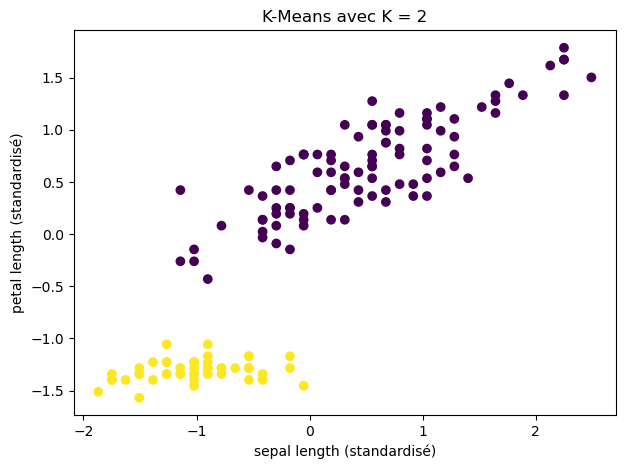

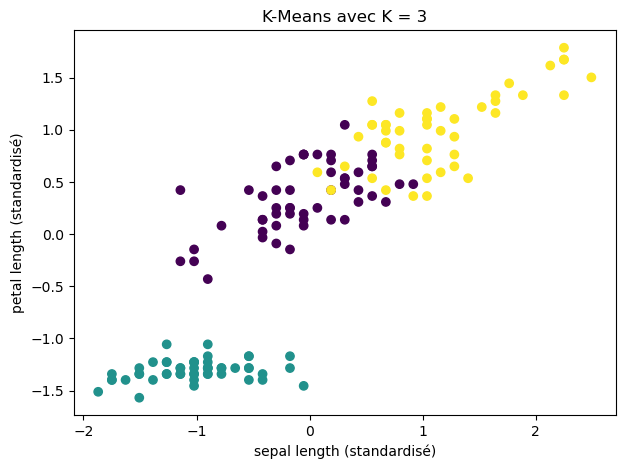

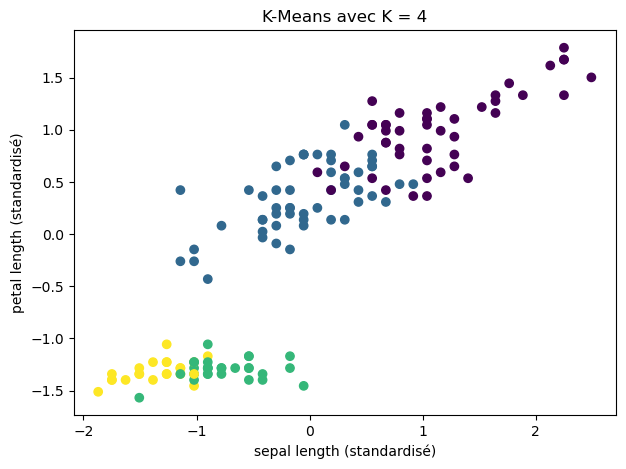

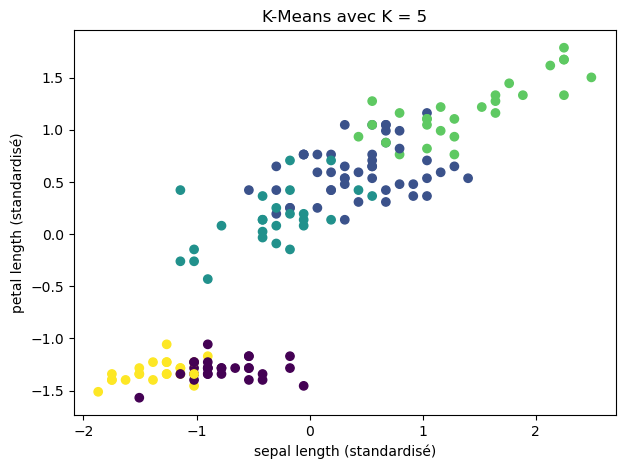

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

k_values = [2, 3, 4, 5]

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_kmeans = kmeans.fit_predict(X_scaled)

    plt.figure(figsize=(7, 5))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 2], c=labels_kmeans)
    plt.xlabel("sepal length (standardisé)")
    plt.ylabel("petal length (standardisé)")
    plt.title(f"K-Means avec K = {k}")
    plt.show()

## Interprétation des résultats de K-Means

Les graphiques montrent que la valeur de **K** change directement la structure des clusters.

avec **K = 2**, les données sont séparées en deux grands groupes. Un groupe en bas du graphique est bien isolé, mais l’autre regroupe encore beaucoup d’observations différentes.

avec **K = 3**, la séparation paraît plus équilibrée. On distingue toujours le groupe bien isolé en bas, tandis que les autres observations sont réparties en deux groupes plus cohérents.

avec **K = 4** et **K = 5**, K-Means commence à diviser davantage les groupes du centre et du haut. Les clusters deviennent plus nombreux, mais aussi un peu moins naturels visuellement.

dans l’ensemble, **K = 3** semble être la valeur la plus adaptée parmi celles testées, car elle donne une séparation plus claire et plus cohérente.

#

## Méthode du coude

Pour compléter l’analyse, nous utilisons la **méthode du coude** afin d’observer à partir de quelle valeur de `K` la diminution de l’inertie devient moins marquée.

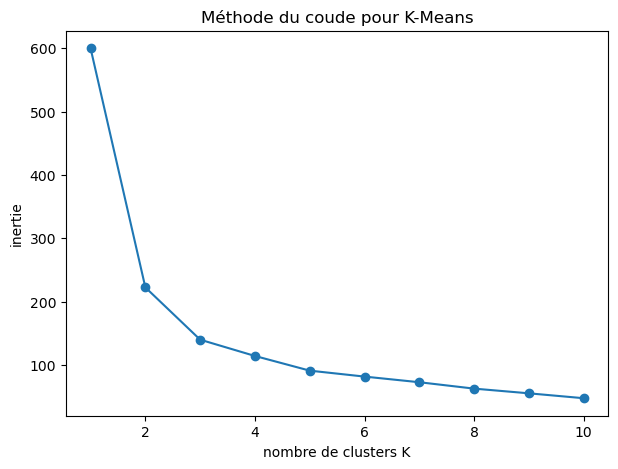

In [24]:
inertias = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertias, marker='o')
plt.xlabel("nombre de clusters K")
plt.ylabel("inertie")
plt.title("Méthode du coude pour K-Means")
plt.show()

## Interprétation de la méthode du coude

La courbe montre que l’inertie diminue fortement entre **K = 1** et **K = 3**, puis la baisse devient plus progressive.

le coude semble donc apparaître autour de **K = 3**. Cela indique que choisir plus de 3 clusters améliore encore le résultat, mais de façon moins importante.

ce résultat confirme donc que **K = 3** est une valeur raisonnable pour la suite de l’analyse avec K-Means.

#

### Valeur retenue pour la suite
Après l’analyse visuelle des clusters et de la courbe d’inertie, nous choisirons une valeur de `K=3 à retenir pour la comparaison finale avec **GMM** et **DBSCAN**.

#

# Expérimentation avec GMM et analyse de l’hyperparamètre K

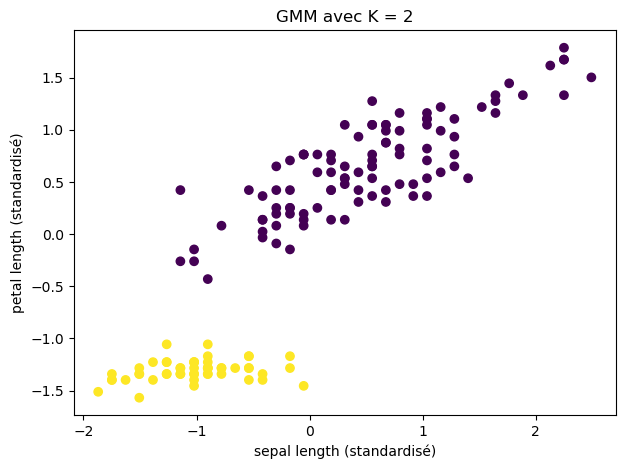

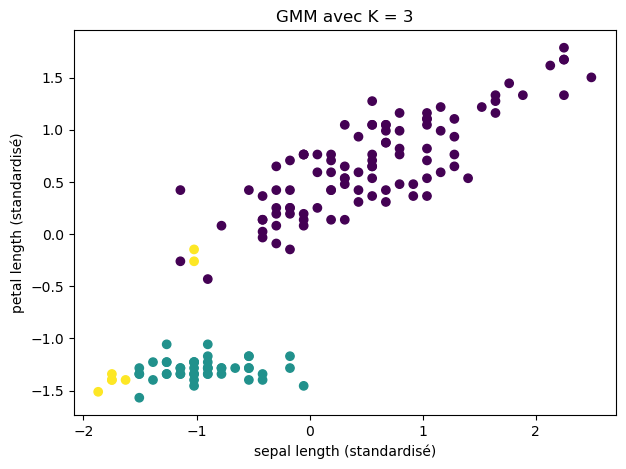

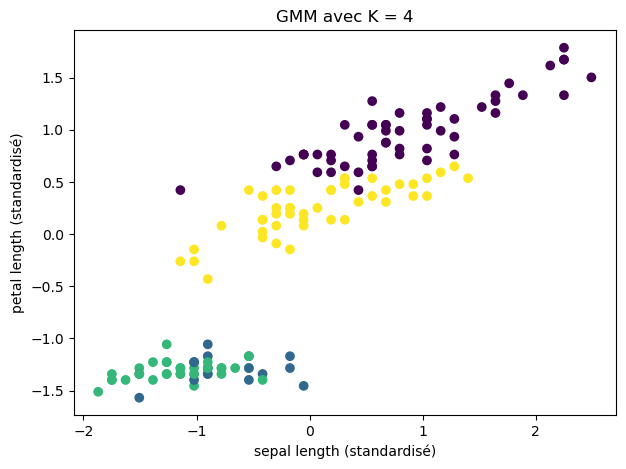

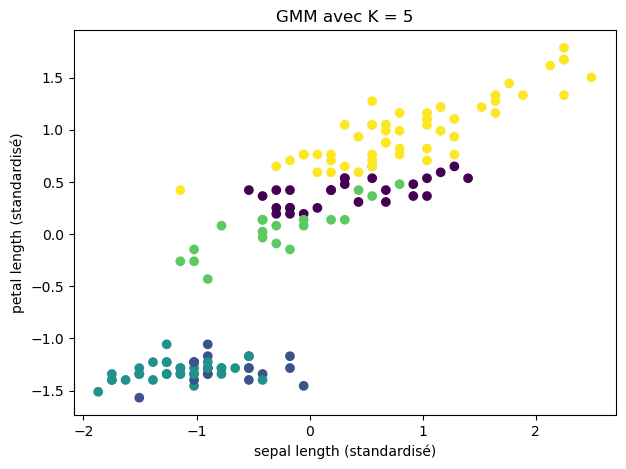

In [31]:
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

k_values = [2, 3, 4, 5]

for k in k_values:
    gmm = GaussianMixture(n_components=k, random_state=42)
    labels_gmm = gmm.fit_predict(X_scaled)

    plt.figure(figsize=(7, 5))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 2], c=labels_gmm)
    plt.xlabel("sepal length (standardisé)")
    plt.ylabel("petal length (standardisé)")
    plt.title(f"GMM avec K = {k}")
    plt.show()

## interprétation des résultats de gmm

les graphiques montrent que le nombre de composantes **k** change clairement la façon dont gmm regroupe les données.

avec **k = 2**, on obtient deux grands groupes. un groupe en bas est bien séparé, tandis que l’autre rassemble presque tout le reste. la séparation est donc simple, mais elle reste un peu trop générale.

avec **k = 3**, le résultat devient plus équilibré. on voit toujours le groupe du bas bien isolé, mais il y a aussi une petite séparation suplémentaire. par contre, la partie du haut reste encore très regroupée.

avec **k = 4**, la structure devient plus détaillée. gmm commence à mieux séparer la zone du milieu et celle du haut, ce qui donne une partition plus fine.

avec **k = 5**, la division est encore plus poussée. les groupes deviennent plus nombreux, mais aussi un peu moins simples à interpréter visuelement.

dans l’ensemble, plus **k** augmente, plus gmm découpe les données en sous-groupes. d’aprés ces graphiques, **k = 4** semble donner un résultat assez intérressant, car la séparation est plus riche que pour `k = 3`, sans étre trop fragmentée comme avec `k = 5`.

## Aide au choix de K

Pour compléter l’analyse, nous utilisons **BIC** et **AIC**, qui sont souvent utilisés avec gmm pour comparer plusieurs valeurs de `K`.

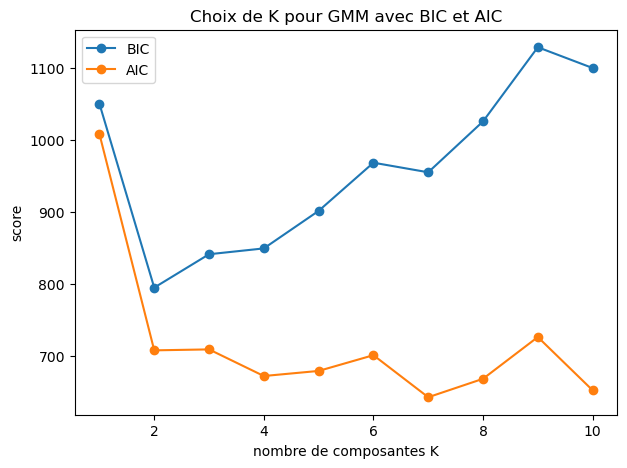

In [36]:
bic_scores = []
aic_scores = []
k_range = range(1, 11)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

plt.figure(figsize=(7, 5))
plt.plot(k_range, bic_scores, marker='o', label='BIC')
plt.plot(k_range, aic_scores, marker='o', label='AIC')
plt.xlabel("nombre de composantes K")
plt.ylabel("score")
plt.title("Choix de K pour GMM avec BIC et AIC")
plt.legend()
plt.show()

## interprétation de bic et aic pour gmm

la courbe montre que les scores **bic** et **aic** diminuent beaucoup au début, puis ils commencent à varier davantage.

pour **bic**, la meilleure valeur semble apparaitre autour de **k = 2**, car c’est là que le score est le plus bas.  
pour **aic**, le minimum semble plutot autour de **k = 7**, mais cette valeur donne un modèle plus complexe.

dans notre cas, on ne va pas choisir seulement selon la courbe, mais aussi selon les graphiques obtenus avant. visuelement, **k = 4** donnait une séparation plus intéressante et plus compréhensible que **k = 2**, tout en restant plus simple que des valeurs trop grandes.

donc, même si **bic** favorise plutot `k = 2`, on peut retenir **k = 4** pour la suite, car ce choix donne un bon compromis entre qualité visuelle et niveau de détail.

#

#

# expérimentation avec dbscan et analyse des hyperparamètres

dans cette partie, nous appliquons notre implémentation manuelle de **dbscan** au dataset iris standardisé.

l’objectif est d’analyser l’effet des hyperparamètres `eps` et `min_samples` sur :
- le nombre de clusters
- la structure des groupes
- la présence de bruit

eps = 0.5, min_samples = 5
nombre de clusters : 2
nombre de points bruit : 34


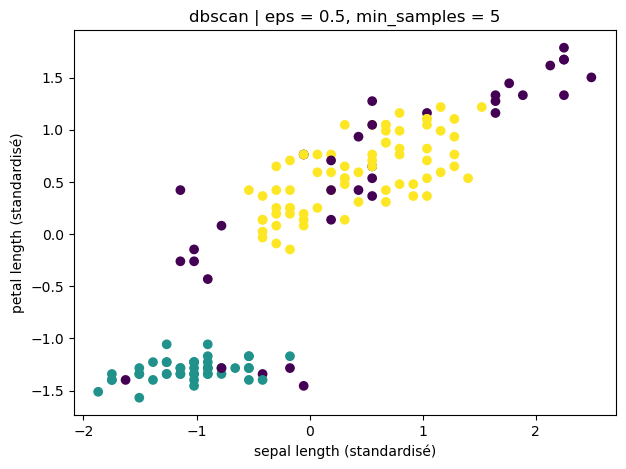

eps = 0.8, min_samples = 5
nombre de clusters : 2
nombre de points bruit : 4


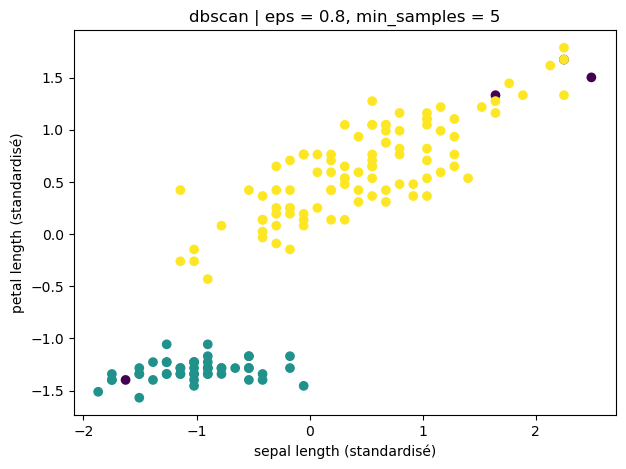

eps = 1.0, min_samples = 5
nombre de clusters : 2
nombre de points bruit : 3


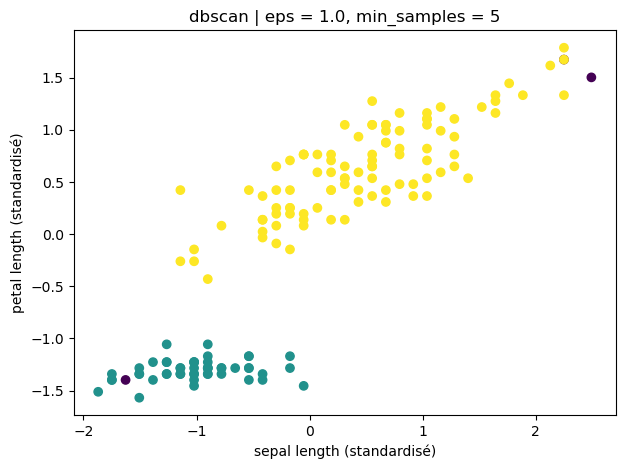

eps = 0.8, min_samples = 3
nombre de clusters : 2
nombre de points bruit : 4


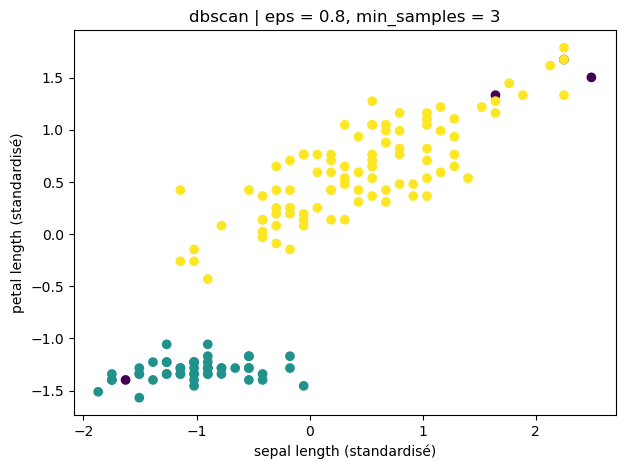

In [43]:
import matplotlib.pyplot as plt
import numpy as np

paramètres = [
    (0.5, 5),
    (0.8, 5),
    (1.0, 5),
    (0.8, 3)
]

for eps, min_samples in paramètres:
    labels_dbscan = dbscan_manual(X_scaled, eps=eps, min_samples=min_samples)

    unique_labels = np.unique(labels_dbscan)
    n_noise = np.sum(labels_dbscan == -1)
    n_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)

    print(f"eps = {eps}, min_samples = {min_samples}")
    print(f"nombre de clusters : {n_clusters}")
    print(f"nombre de points bruit : {n_noise}")

    plt.figure(figsize=(7, 5))
    plt.scatter(X_scaled[:, 0], X_scaled[:, 2], c=labels_dbscan)
    plt.xlabel("sepal length (standardisé)")
    plt.ylabel("petal length (standardisé)")
    plt.title(f"dbscan | eps = {eps}, min_samples = {min_samples}")
    plt.show()

## interprétation des résultats de dbscan

les résultats montrent que **dbscan** trouve ici **2 clusters** dans tous les cas testés, mais que la quantité de **bruit** change selon les paramétres.

avec **eps = 0.5** et **min_samples = 5**, on obtient beaucoup plus de bruit, avec **34 points** isolés. cela montre que le rayon est trop petit, donc plusieurs points ne trouvent pas assez de voisins.

quand on passe à **eps = 0.8** puis **eps = 1.0** avec `min_samples = 5`, le nombre de points bruit baisse fortement, de **4** puis **3**. les clusters deviennent donc plus stables et plus compacts.

avec **eps = 0.8** et **min_samples = 3**, le résultat reste trés proche de celui obtenu avec `min_samples = 5`, avec encore **2 clusters** et **4 points bruit**.

dans l’ensemble, on voit que **eps** a ici plus d’impact que `min_samples`. plus `eps` augmente, plus dbscan relie les points entre eux et réduit le bruit.

#

#

# comparaison des trois algorithmes

dans cette partie, nous comparons **k-means**, **gmm** et **dbscan** à partir des résultats obtenus sur le dataset iris.

l’objectif est de résumer leurs différences en termes de :
- nombre de clusters
- structure des groupes
- présence de bruit

In [53]:
# résumé simple des choix retenus
print("k-means retenu : K = 3")
print("gmm retenu : K = 4")
print("dbscan retenu : eps = 0.8, min_samples = 5")

k-means retenu : K = 3
gmm retenu : K = 4
dbscan retenu : eps = 0.8, min_samples = 5


## tableau comparatif

In [56]:
import pandas as pd

comparaison = pd.DataFrame({
    "algorithme": ["k-means", "gmm", "dbscan"],
    "hyperparamètres retenus": ["K = 3", "K = 4", "eps = 0.8, min_samples = 5"],
    "nombre de clusters observés": [3, 4, 2],
    "bruit détecté": ["non", "non", "oui"],
    "remarque": [
        "séparation claire et cohérente",
        "partition plus fine et plus souple",
        "2 clusters avec quelques points bruit"
    ]
})

comparaison

,algorithme,hyperparamètres retenus,nombre de clusters observés,bruit détecté,remarque
0,k-means,K = 3,3,non,séparation claire et cohérente
1,gmm,K = 4,4,non,partition plus fine et plus souple
2,dbscan,"eps = 0.8, min_samples = 5",2,oui,2 clusters avec quelques points bruit


## visualisation finale

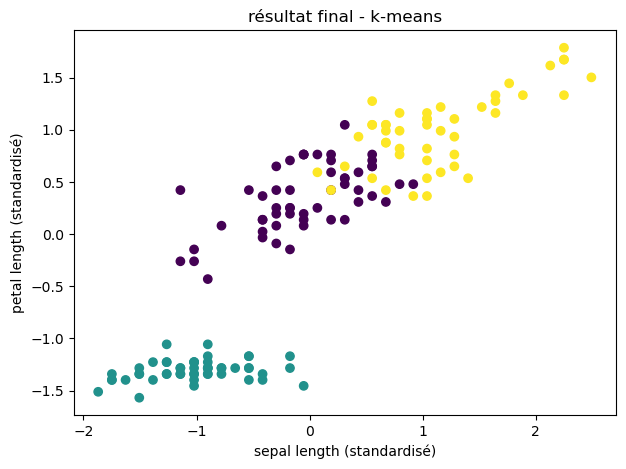

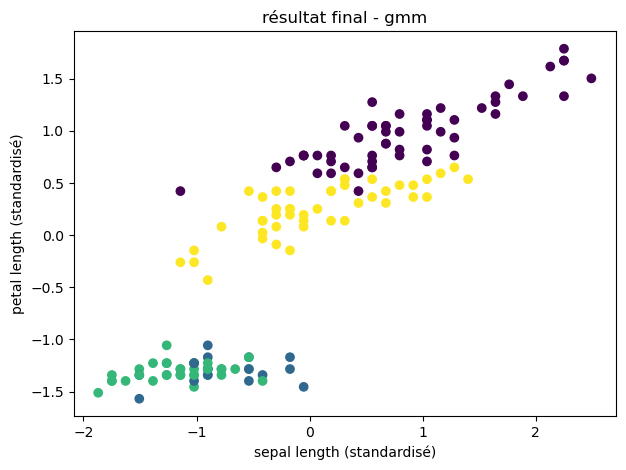

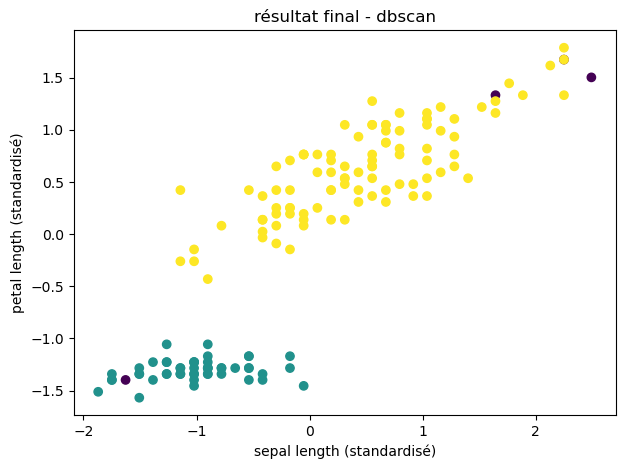

In [59]:
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# k-means final
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_final = kmeans_final.fit_predict(X_scaled)

# gmm final
gmm_final = GaussianMixture(n_components=4, random_state=42)
labels_gmm_final = gmm_final.fit_predict(X_scaled)

# dbscan final
labels_dbscan_final = dbscan_manual(X_scaled, eps=0.8, min_samples=5)

# affichage séparé
plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 2], c=labels_kmeans_final)
plt.xlabel("sepal length (standardisé)")
plt.ylabel("petal length (standardisé)")
plt.title("résultat final - k-means")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 2], c=labels_gmm_final)
plt.xlabel("sepal length (standardisé)")
plt.ylabel("petal length (standardisé)")
plt.title("résultat final - gmm")
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 2], c=labels_dbscan_final)
plt.xlabel("sepal length (standardisé)")
plt.ylabel("petal length (standardisé)")
plt.title("résultat final - dbscan")
plt.show()

# comparaison des trois algorithmes

dans cette partie, nous résumons les principaux résultats obtenus avec **k-means**, **gmm** et **dbscan** sur le dataset iris.

la comparaison porte surtout sur :
- le nombre de clusters obtenus
- la structure générale des groupes
- la présence ou non de bruit

## résumé comparatif

dans nos résultats, **k-means** avec `k = 3` a donné une séparation assez claire et équilibrée. avec `k = 2`, les groupes restaient trop généraux, tandis qu’avec `k = 4` et `k = 5`, les données étaient davantage découpées, ce qui rendait la lecture moins naturelle. c’est donc pour cela que `k = 3` a été retenu.

pour **gmm**, on a observé que lorsque `k` augmente, la partition devient plus détaillée. avec `k = 2`, la séparation restait assez large, alors qu’avec `k = 4`, les groupes étaient plus fins et plus intéressants visuellement. avec `k = 5`, la séparation devenait plus poussée, mais aussi un peu moins simple à interpréter. dans nos essais, `k = 4` donnait donc un bon compromis.

pour **dbscan**, le résultat était différent des deux autres. dans tous les tests, il a trouvé **2 clusters**, mais la quantité de bruit a changé selon les paramètres. avec `eps = 0.5`, il y avait beaucoup plus de points isolés, alors qu’avec `eps = 0.8` et `eps = 1.0`, le bruit diminuait nettement. cela montre que dbscan était ici très sensible au choix de `eps`.

si on compare les trois résultats retenus, **k-means** donne la séparation la plus simple, **gmm** donne la partition la plus détaillée, et **dbscan** est le seul à avoir mis en évidence du bruit. nos résultats montrent donc que les trois méthodes ne décrivent pas exactement la structure du dataset de la méme façon.

## remarque générale

nos résultats montrent que les trois algorithmes donnent des partitions différentes du dataset iris. k-means donne une séparation plus simple, gmm une partition plus détaillée, tandis que dbscan met surtout en évidence le bruit et l’effet de la densité.